In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [45]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [47]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [48]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [49]:
# scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Age'] = scaler.fit_transform(df[['Age']])
df['Annual Income (k$)'] = scaler.fit_transform(df[['Annual Income (k$)']])
df['Spending Score (1-100)'] = scaler.fit_transform(df[['Spending Score (1-100)']])

In [50]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,2.000000e+02,2.000000e+02,2.000000e+02
mean,100.500000,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,57.879185,1.002509e+00,1.002509e+00,1.002509e+00
min,1.000000,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,50.750000,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,100.500000,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,150.250000,7.284319e-01,6.656748e-01,8.851316e-01
max,200.000000,2.235532e+00,2.917671e+00,1.894492e+00


In [51]:
# genre => one-hot encoding
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,-1.424569,-1.738999,-0.434801,True
1,2,-1.281035,-1.738999,1.195704,True
2,3,-1.352802,-1.700830,-1.715913,False
3,4,-1.137502,-1.700830,1.040418,False
4,5,-0.563369,-1.662660,-0.395980,False


In [52]:
X = df.drop('CustomerID', axis=1)
K = 5
model = KMeans(n_clusters=K, random_state=42)
model.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [53]:
labels = model.labels_
df['Cluster'] = labels
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,Cluster
0,1,-1.424569,-1.738999,-0.434801,True,2
1,2,-1.281035,-1.738999,1.195704,True,4
2,3,-1.352802,-1.700830,-1.715913,False,2
3,4,-1.137502,-1.700830,1.040418,False,4
4,5,-0.563369,-1.662660,-0.395980,False,2


In [54]:
centroids = model.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=X.columns)
centroids_df.head()

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1.198627,-0.460981,-0.327038,0.431034
1,-0.441917,0.991583,1.239503,0.461538
2,-0.781722,-0.403069,-0.215914,0.340426
3,0.173295,1.066454,-1.298010,0.588235
4,-0.974396,-1.329545,1.132178,0.409091


In [55]:
df = pd.read_csv('Mall_Customers.csv')
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]
K = 8
X_scaled = scaler.fit_transform(X)
model = KMeans(n_clusters=K, random_state=42)
model.fit(X_scaled)
labels = model.labels_
df['Cluster'] = labels
inertia = model.inertia_
centroids = model.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_unscaled, columns=features)

In [56]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [57]:
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


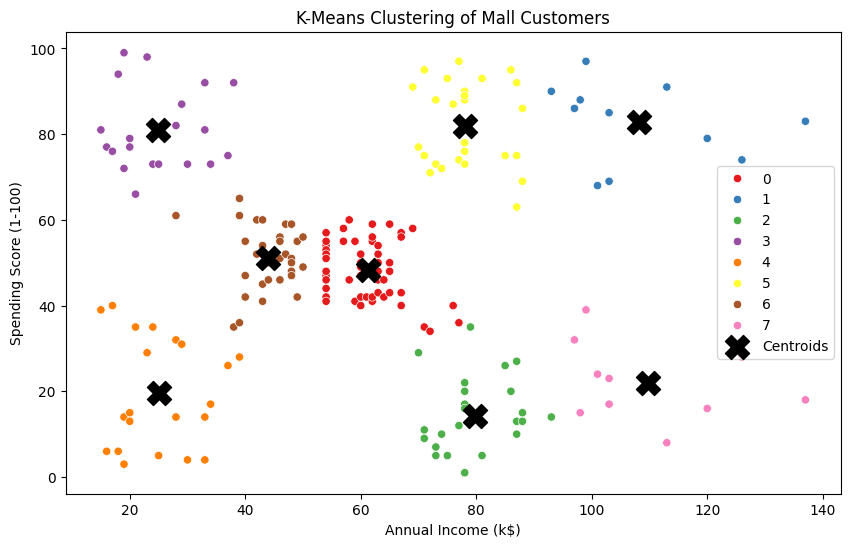

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.scatter(centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'], s=300, c='black', marker='X', label='Centroids')
plt.title('K-Means Clustering of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

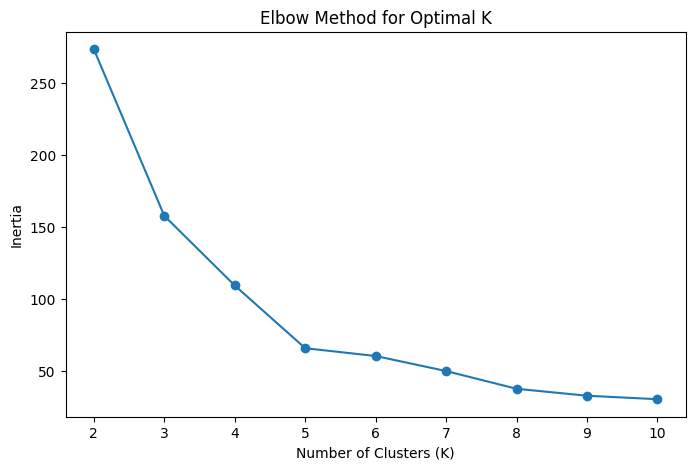

In [59]:
list_ks = range(2, 11)
inertias = []

for k in list_ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list_ks, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

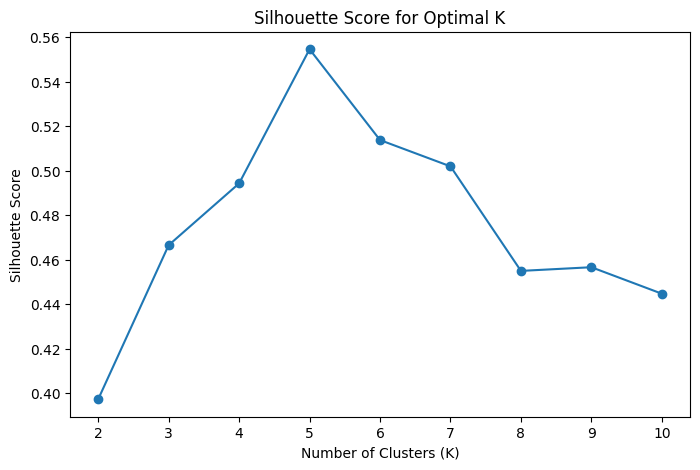

In [60]:
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

silhouette_scores = []
for k in list_ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list_ks, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [61]:
features = ['Age', 'Genre', 'Annual Income (k$)', 'Spending Score (1-100)']
df = pd.read_csv('Mall_Customers.csv')
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


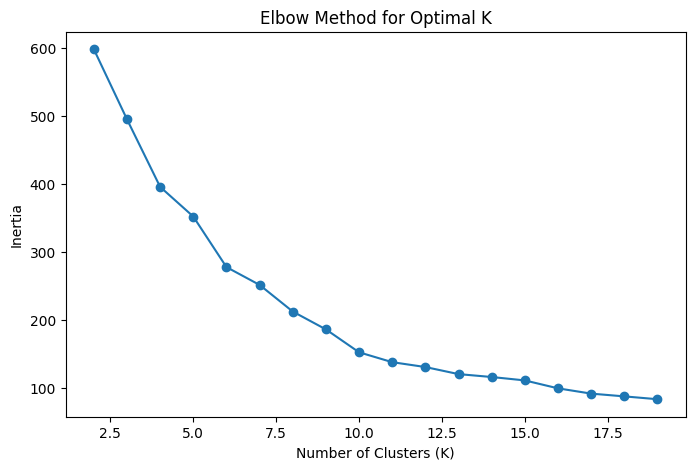

In [62]:
X = df.drop('CustomerID', axis=1)
X_scaled = scaler.fit_transform(X)
list_ks = range(2, 20)
inertias = []
for k in list_ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list_ks, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

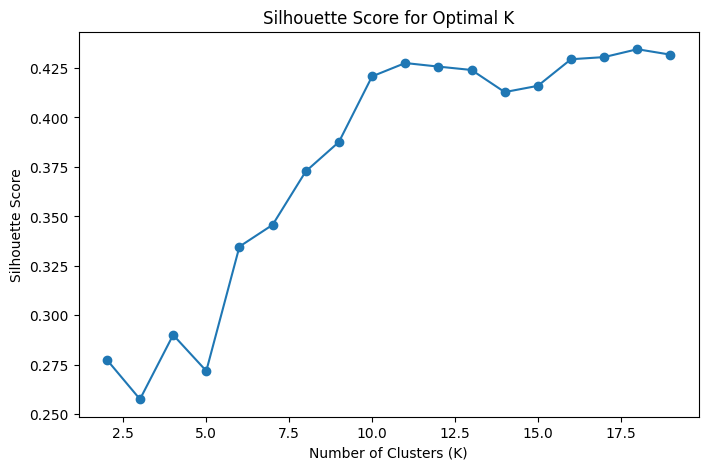

In [63]:
silhouette_scores = []
for k in list_ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list_ks, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [64]:
from sklearn.datasets import load_wine
df_wine = load_wine()
df_wine = pd.DataFrame(df_wine.data, columns=df_wine.feature_names)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [65]:
df_wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [66]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

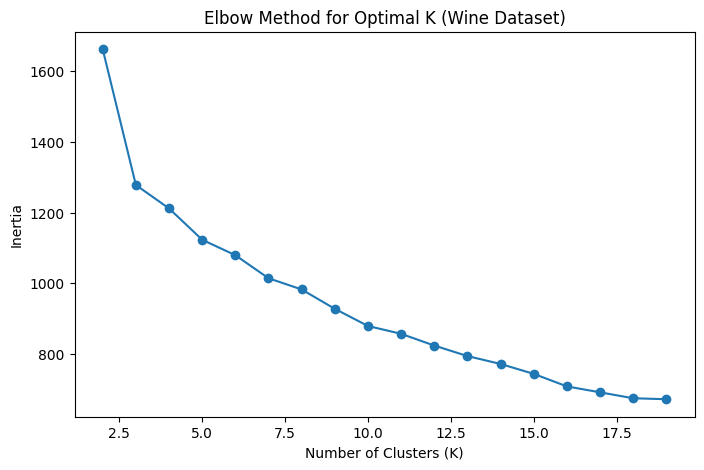

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wine)
list_ks = range(2, 20)
inertias = []
for k in list_ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list_ks, inertias, marker='o')
plt.title('Elbow Method for Optimal K (Wine Dataset)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

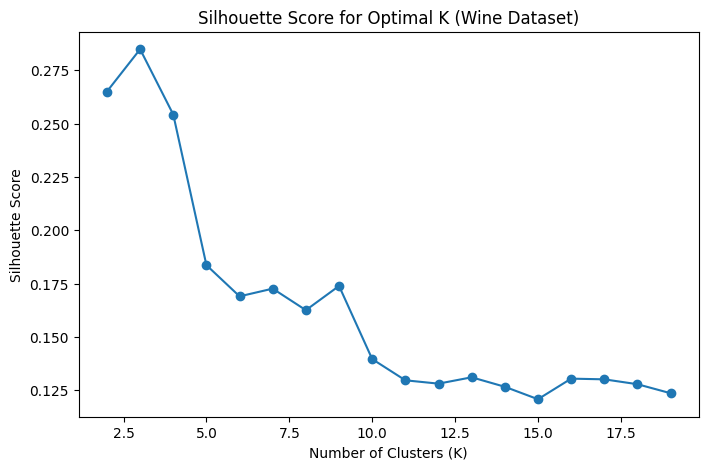

In [68]:
silhouette_scores = []
for k in list_ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list_ks, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K (Wine Dataset)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()